In [1]:
# inciso 1
import os
import sys
import time
import subprocess
import importlib.util
import numpy as np
import pandas as pd

if importlib.util.find_spec("pyreadr") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyreadr"])

import pyreadr

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

RANDOM_STATE = 123
TEST_SIZE = 0.30

ruta_bd = "data/listings.RData"

objetos = pyreadr.read_r(ruta_bd)
listings = objetos["listings"].copy()

listings["price_num"] = (
    listings["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
listings["price_num"] = pd.to_numeric(listings["price_num"], errors="coerce")

columnas_numericas = [
    "latitude",
    "longitude",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "minimum_minimum_nights",
    "maximum_minimum_nights",
    "minimum_maximum_nights",
    "maximum_maximum_nights",
    "minimum_nights_avg_ntm",
    "maximum_nights_avg_ntm",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "availability_eoy",
    "number_of_reviews_ly",
    "estimated_occupancy_l365d",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "reviews_per_month"
]

columnas_categoricas = [
    "source",
    "host_response_time",
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "neighbourhood_cleansed",
    "neighbourhood_group_cleansed",
    "property_type",
    "room_type",
    "has_availability",
    "instant_bookable",
    "city"
]

columnas_numericas = [col for col in columnas_numericas if col in listings.columns]
columnas_categoricas = [col for col in columnas_categoricas if col in listings.columns]
columnas_modelo = columnas_numericas + columnas_categoricas

base_modelo = listings[columnas_modelo + ["price_num", "id"]].copy()
base_modelo = base_modelo.dropna(subset=["price_num"])
base_modelo = base_modelo[base_modelo["price_num"] > 0].copy()

for col in columnas_numericas:
    base_modelo[col] = pd.to_numeric(base_modelo[col], errors="coerce")

base_modelo[columnas_numericas] = base_modelo[columnas_numericas].replace([np.inf, -np.inf], np.nan)

q1, q2 = base_modelo["price_num"].quantile([1/3, 2/3])
base_modelo["categoria_precio"] = np.select(
    [base_modelo["price_num"] <= q1, base_modelo["price_num"] <= q2],
    ["barata", "media"],
    default="cara"
)

X = base_modelo[columnas_modelo]
y = base_modelo["categoria_precio"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

id_train = base_modelo.loc[X_train.index, "id"]
id_test = base_modelo.loc[X_test.index, "id"]

X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts()

((53372, 48),
 (22874, 48),
 categoria_precio
 barata    17982
 cara      17783
 media     17607
 Name: count, dtype: int64,
 categoria_precio
 barata    7707
 cara      7621
 media     7546
 Name: count, dtype: int64)

In [2]:
# inciso 2
variable_respuesta = "categoria_precio"
orden_categorias = ["barata", "media", "cara"]
label_encoder = LabelEncoder()
y_train_cod = label_encoder.fit_transform(y_train)
y_test_cod = label_encoder.transform(y_test)

resumen_variable_respuesta = pd.DataFrame({
    "categoria": orden_categorias,
    "train": y_train.value_counts().reindex(orden_categorias).values,
    "test": y_test.value_counts().reindex(orden_categorias).values
})

resumen_variable_respuesta

,categoria,train,test
0,barata,17982,7707
1,media,17607,7546
2,cara,17783,7621


In [3]:
# inciso 3
def crear_preprocesador():
    transformador_numerico = Pipeline(steps=[
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler(with_mean=False))
    ])
    try:
        codificador = OneHotEncoder(handle_unknown="ignore", min_frequency=20)
    except TypeError:
        codificador = OneHotEncoder(handle_unknown="ignore")
    transformador_categorico = Pipeline(steps=[
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("codificador", codificador)
    ])
    return ColumnTransformer(transformers=[
        ("numericas", transformador_numerico, columnas_numericas),
        ("categoricas", transformador_categorico, columnas_categoricas)
    ])

modelo_rna_1 = Pipeline(steps=[
    ("preprocesador", crear_preprocesador()),
    ("rna", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=100,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    ))
])

modelo_rna_2 = Pipeline(steps=[
    ("preprocesador", crear_preprocesador()),
    ("rna", MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="tanh",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.0005,
        max_iter=100,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    ))
])

topologias = pd.DataFrame([
    {"modelo": "RNA 1", "capas_ocultas": "64, 32", "activacion": "relu"},
    {"modelo": "RNA 2", "capas_ocultas": "128, 64, 32", "activacion": "tanh"}
])

tiempo_inicio = time.time()
modelo_rna_1.fit(X_train, y_train_cod)
tiempo_modelo_1 = time.time() - tiempo_inicio

tiempo_inicio = time.time()
modelo_rna_2.fit(X_train, y_train_cod)
tiempo_modelo_2 = time.time() - tiempo_inicio

topologias["tiempo_entrenamiento_segundos"] = [tiempo_modelo_1, tiempo_modelo_2]
topologias

C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


,modelo,capas_ocultas,activacion,tiempo_entrenamiento_segundos
0,RNA 1,"64, 32",relu,33.243225
1,RNA 2,"128, 64, 32",tanh,80.243875


In [4]:
# inciso 4
prediccion_modelo_1_cod = modelo_rna_1.predict(X_test)
prediccion_modelo_2_cod = modelo_rna_2.predict(X_test)

prediccion_modelo_1 = label_encoder.inverse_transform(prediccion_modelo_1_cod)
prediccion_modelo_2 = label_encoder.inverse_transform(prediccion_modelo_2_cod)

resultados_prediccion = pd.DataFrame({
    "id": id_test.values,
    "categoria_real": y_test.values,
    "prediccion_rna_1": prediccion_modelo_1,
    "prediccion_rna_2": prediccion_modelo_2
})

resumen_prediccion = pd.DataFrame([
    {"modelo": "RNA 1", "accuracy_test": accuracy_score(y_test_cod, prediccion_modelo_1_cod)},
    {"modelo": "RNA 2", "accuracy_test": accuracy_score(y_test_cod, prediccion_modelo_2_cod)}
])

resultados_prediccion.to_csv("predicciones_clasificacion_rna_inciso_4.csv", index=False)

resumen_prediccion

C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


,modelo,accuracy_test
0,RNA 1,0.742546
1,RNA 2,0.746830


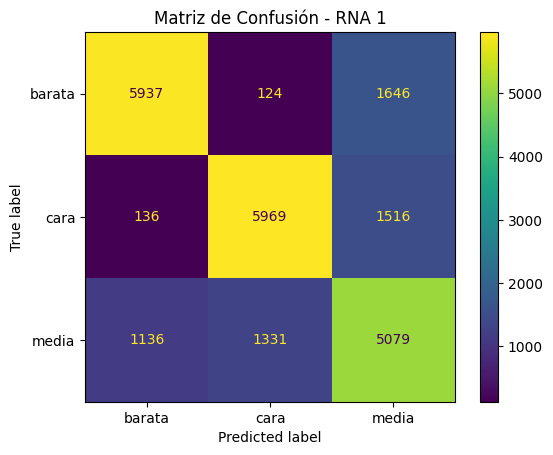

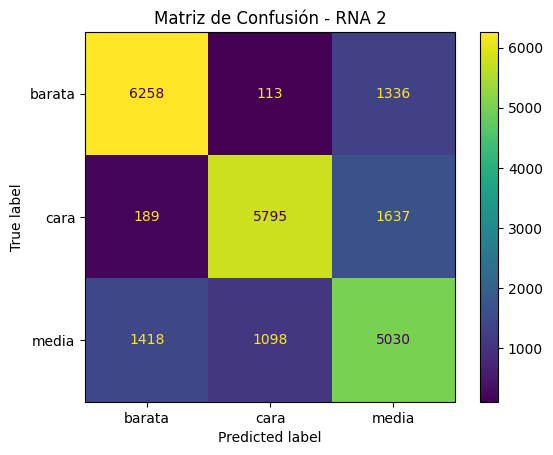

Matriz RNA 1
[[5937  124 1646]
 [ 136 5969 1516]
 [1136 1331 5079]]

Matriz RNA 2
[[6258  113 1336]
 [ 189 5795 1637]
 [1418 1098 5030]]


In [5]:
#inciso 5
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_modelo_1 = confusion_matrix(y_test_cod, prediccion_modelo_1_cod)
cm_modelo_2 = confusion_matrix(y_test_cod, prediccion_modelo_2_cod)

disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm_modelo_1,
    display_labels=label_encoder.classes_
)
disp1.plot()
plt.title("Matriz de Confusión - RNA 1")
plt.show()

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_modelo_2,
    display_labels=label_encoder.classes_
)
disp2.plot()
plt.title("Matriz de Confusión - RNA 2")
plt.show()




print("Matriz RNA 1")
print(cm_modelo_1)

print("\nMatriz RNA 2")
print(cm_modelo_2)

In [6]:
##inciso 6
print(resumen_prediccion)
print(topologias)

  modelo  accuracy_test
0  RNA 1       0.742546
1  RNA 2       0.746830
  modelo capas_ocultas activacion  tiempo_entrenamiento_segundos
0  RNA 1        64, 32       relu                      33.243225
1  RNA 2   128, 64, 32       tanh                      80.243875


In [ ]:
#inciso 7 
from sklearn.metrics import accuracy_score

# Accuracy en entrenamiento
acc_train_1 = accuracy_score(y_train_cod, modelo_rna_1.predict(X_train))
acc_train_2 = accuracy_score(y_train_cod, modelo_rna_2.predict(X_train))

# Accuracy en prueba 
acc_test_1 = accuracy_score(y_test_cod, prediccion_modelo_1_cod)
acc_test_2 = accuracy_score(y_test_cod, prediccion_modelo_2_cod)

comparacion_overfitting = pd.DataFrame([
    {"modelo": "RNA 1", "train": acc_train_1, "test": acc_test_1},
    {"modelo": "RNA 2", "train": acc_train_2, "test": acc_test_2}
])

comparacion_overfitting

C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


,modelo,train,test
0,RNA 1,0.784288,0.742546
1,RNA 2,0.793750,0.746830


In [8]:
#inciso 8 
#mejor modelo: RNA 2
modelo_rna_2_tuneado = Pipeline(steps=[
    ("preprocesador", crear_preprocesador()),
    ("rna", MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="tanh",
        solver="adam",
        alpha=0.0005,             
        learning_rate_init=0.0008, 
        max_iter=200,              
        early_stopping=True,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    ))
])

# Entrenar
modelo_rna_2_tuneado.fit(X_train, y_train_cod)

# Evaluar
pred_tuneado = modelo_rna_2_tuneado.predict(X_test)

from sklearn.metrics import accuracy_score

acc_tuneado = accuracy_score(y_test_cod, pred_tuneado)

acc_tuneado

C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


0.7473113578735683

In [9]:
#inciso 9
#variable respuesta para regresion: price_num
y_reg= base_modelo["price_num"]

#indices del split anterior
y_train_reg = y_reg.loc[X_train.index]
y_test_reg = y_reg.loc[X_test.index]


In [10]:
#inciso 10 
from sklearn.neural_network import MLPRegressor

# Modelo 1 
modelo_rna_reg_1 = Pipeline(steps=[
    ("preprocesador", crear_preprocesador()),
    ("rna", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

# Modelo 2 
modelo_rna_reg_2 = Pipeline(steps=[
    ("preprocesador", crear_preprocesador()),
    ("rna", MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation="tanh",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.0005,
        max_iter=200,
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

# Entrenamiento
modelo_rna_reg_1.fit(X_train, y_train_reg)
modelo_rna_reg_2.fit(X_train, y_train_reg)

C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) r

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesador', ...), ('rna', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [12]:
#predicciones
pred_reg_1 = modelo_rna_reg_1.predict(X_test)
pred_reg_2 = modelo_rna_reg_2.predict(X_test)

#metricas de evaluación
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluar_modelo(y_real, y_pred):
    return {
        "RMSE": mean_squared_error(y_real, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_real, y_pred),
        "R2": r2_score(y_real, y_pred)
    }

resultados_reg_1 = evaluar_modelo(y_test_reg, pred_reg_1)
resultados_reg_2 = evaluar_modelo(y_test_reg, pred_reg_2)

resultados_reg_1, resultados_reg_2

C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


({'RMSE': 1892.3237578530182,
  'MAE': 393.55628349936313,
  'R2': 0.8012131153400841},
 {'RMSE': 4219.659338796297,
  'MAE': 553.671145339482,
  'R2': 0.011557010147616675})

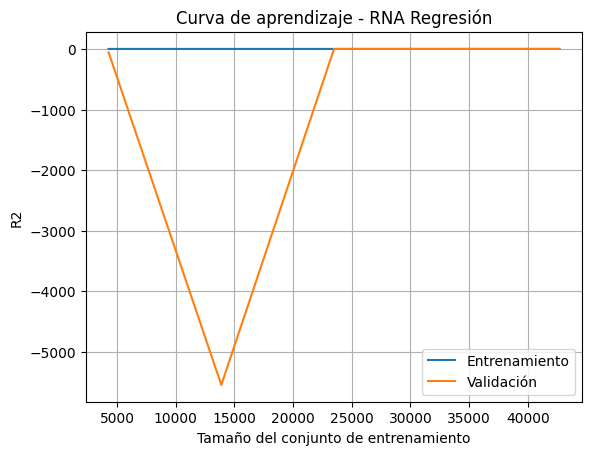

In [13]:
#inciso 12
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    modelo_rna_reg_1,
    X_train,
    y_train_reg,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# Promedios
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Gráfica
plt.figure()
plt.plot(train_sizes, train_mean, label="Entrenamiento")
plt.plot(train_sizes, val_mean, label="Validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("R2")
plt.title("Curva de aprendizaje - RNA Regresión")
plt.legend()
plt.grid()
plt.show()

In [14]:
#Mejor modelo: RNA 1
#modelo tuneado 
modelo_rna_reg_1_tuneado = Pipeline(steps=[
    ("preprocesador", crear_preprocesador()),
    ("rna", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.00005,              # menos regularización
        learning_rate_init=0.0008,  # ajuste leve
        max_iter=300,               # más iteraciones
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

# Entrenar
modelo_rna_reg_1_tuneado.fit(X_train, y_train_reg)

# Predecir
pred_reg_tuneado = modelo_rna_reg_1_tuneado.predict(X_test)

C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Elvir\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [15]:
resultados_tuneado = evaluar_modelo(y_test_reg, pred_reg_tuneado)

resultados_tuneado

{'RMSE': 1872.358087053603,
 'MAE': 368.17215434984104,
 'R2': 0.8053857372051679}